In [19]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

# --- CONFIGURATION SEMESTRE 3 ---
features_s3 = [
    "Structure des données", "C++", "Database Relationnelle",
    "Compilation", "Soft Skills", "Analyse Numérique", "Électronique"
]

# Dataset S3 (20 étudiants)
X_s3 = np.array([
    [15,14,16,13,17,14,15], [8,9,7,10,8,9,11], [12,11,13,14,12,10,12], [5,6,7,8,5,6,5],
    [17,14,16,15,18,17,16], [9,10,8,9,11,10,9], [13,12,11,14,13,12,14], [4,5,6,5,4,5,3],
    [16,15,14,17,16,18,17], [7,8,9,7,8,7,8], [11,10,12,11,10,11,12], [6,7,5,6,7,6,4],
    [14,13,15,14,13,14,15], [10,9,10,11,9,10,11], [18,17,16,18,17,18,19], [3,4,5,4,3,4,2],
    [12,13,12,11,14,13,13], [8,7,8,9,7,8,9], [15,16,15,14,15,16,15], [5,5,6,5,6,5,4]
])

y_svm = np.array([1 if np.mean(e) >= 10 else -1 for e in X_s3])
y_cart = np.array(["Réussite" if val == 1 else "Échec" for val in y_svm])

def entropie(labels):
    n = len(labels)
    if n == 0: return 0
    counts = Counter(labels)
    return -sum((c/n) * math.log2(c/n) for c in counts.values())

def executer_analyse_s3(X, y):
    h_init = entropie(y)
    gains_par_module = []

    print(f"--- ANALYSE CART ---")
    print(f"Entropie initiale H(S): {round(h_init, 4)}\n")

    for i in range(X.shape[1]):
        mask = X[:, i] < 10
        y_g, y_d = y[mask], y[~mask]
        gain = h_init - (len(y_g)/len(y)*entropie(y_g) + len(y_d)/len(y)*entropie(y_d))
        gains_par_module.append(gain)

    m_feat = np.argmax(gains_par_module)

    print("RÉSULTAT GLOBAL")
    print(f"Meilleur module : {features_s3[m_feat]}")
    print(f"Seuil : 10")
    print(f"Gain max : {round(gains_par_module[m_feat], 4)}")
    print("-" * 40)
    print("\n--- GAINS PAR MODULE ---")
    for i, g in enumerate(gains_par_module):
        print(f"{features_s3[i]} : Gain = {round(g, 4)}")

    print(f"\n MEILLEUR MODULE GLOBAL : {features_s3[m_feat]}")
    return m_feat

best_idx = executer_analyse_s3(X_s3, y_cart)

--- ANALYSE CART ---
Entropie initiale H(S): 0.9928

RÉSULTAT GLOBAL
Meilleur module : Structure des données
Seuil : 10
Gain max : 0.9928
----------------------------------------

--- GAINS PAR MODULE ---
Structure des données : Gain = 0.9928
C++ : Gain = 0.5246
Database Relationnelle : Gain = 0.9928
Compilation : Gain = 0.7445
Soft Skills : Gain = 0.5246
Analyse Numérique : Gain = 0.7445
Électronique : Gain = 0.7445

 MEILLEUR MODULE GLOBAL : Structure des données


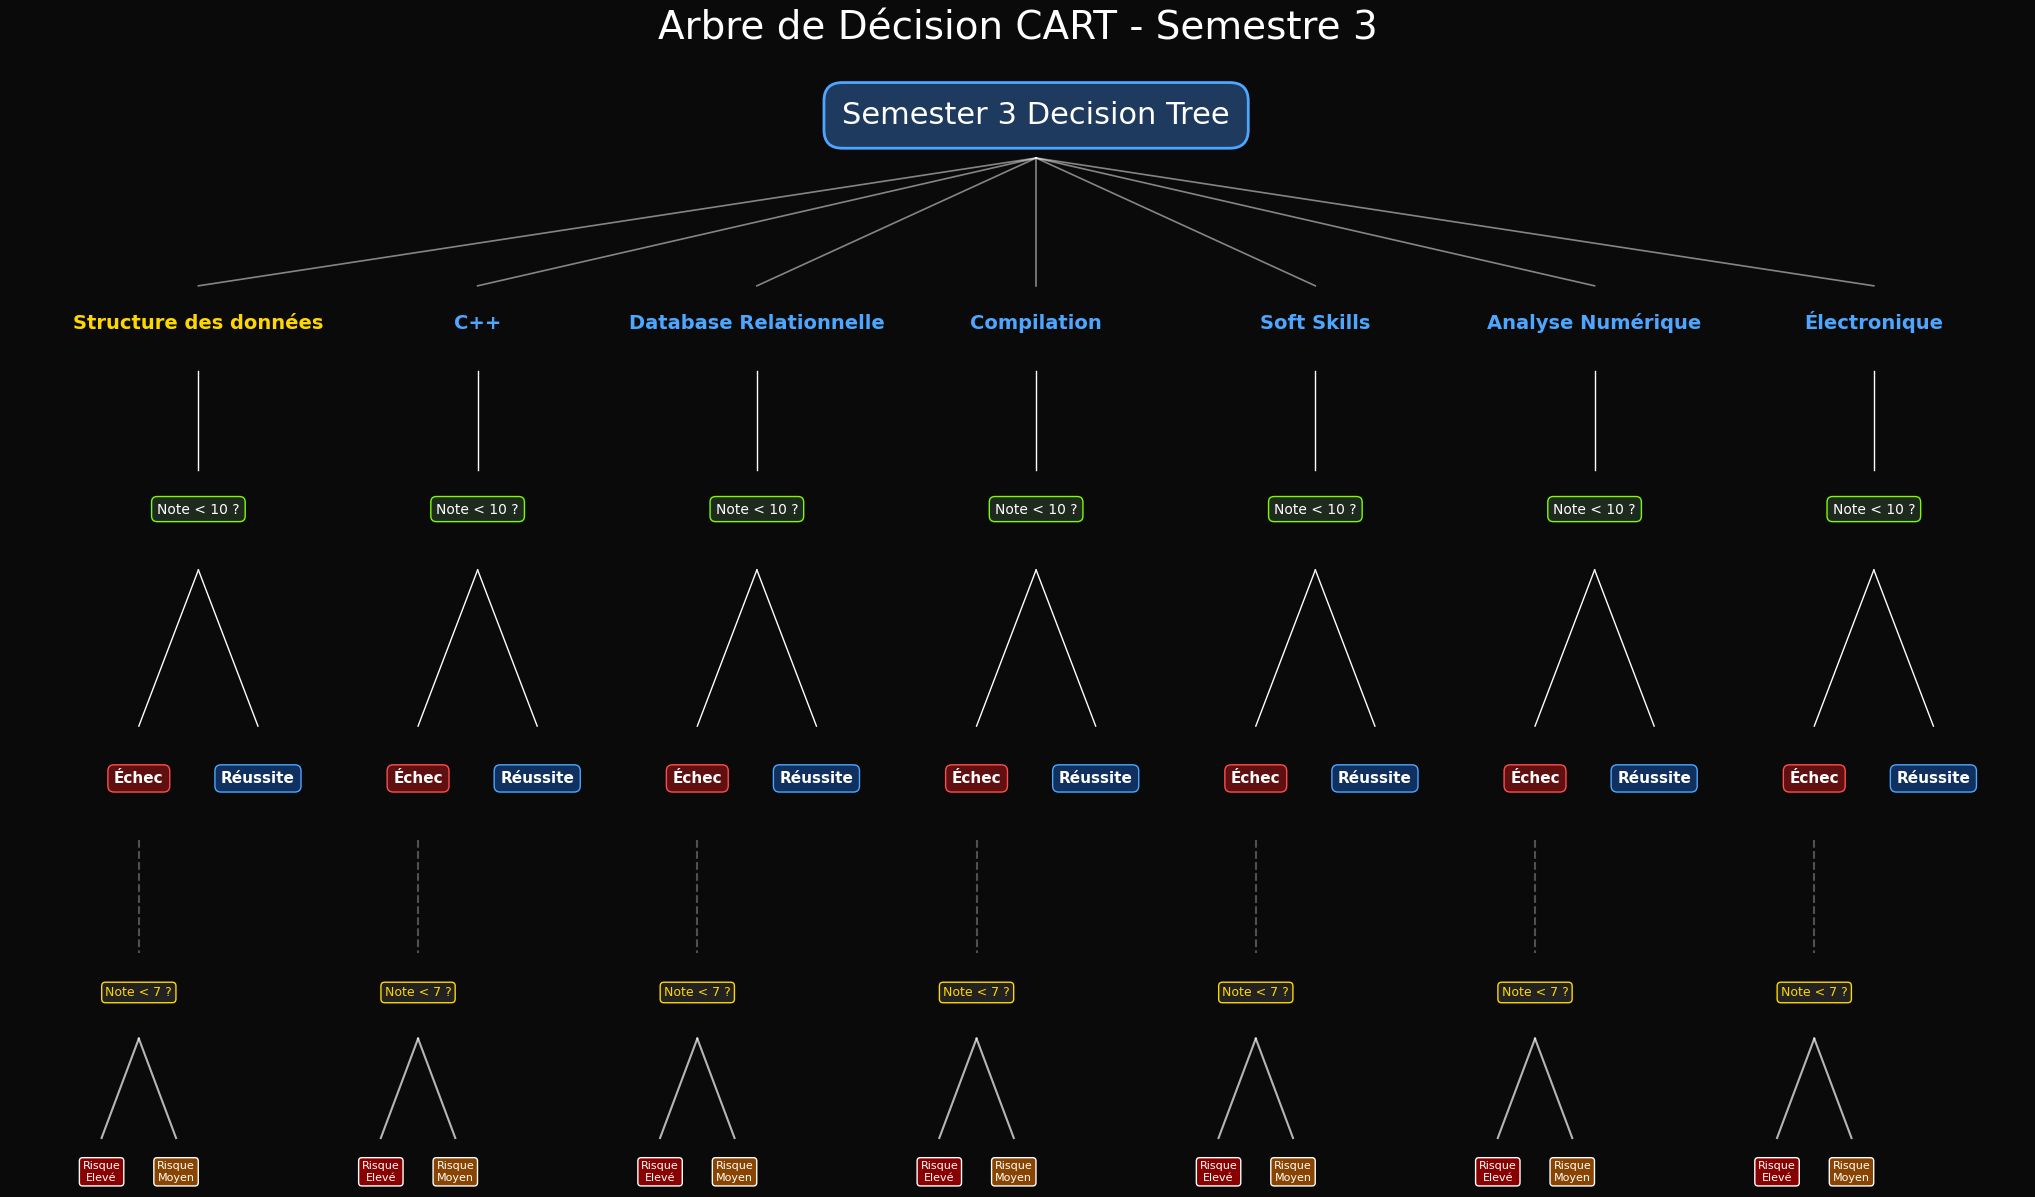

In [20]:
def visualize_cart_s3_deep():
    fig, ax = plt.subplots(figsize=(26, 14))
    fig.patch.set_facecolor("#0A0A0A")
    ax.set_facecolor("#0A0A0A")
    ax.axis('off')

    plt.title("Arbre de Décision CART - Semestre 3", fontsize=28, color='white', pad=50)

    # Racine
    ax.text(0.5, 0.95, "Semester 3 Decision Tree", ha='center', va='center', fontsize=22, color='white',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#1E3A5F", edgecolor="#4DA6FF", linewidth=2))

    pos = np.linspace(0.05, 0.95, len(features_s3))

    for i, mod in enumerate(features_s3):
        x = pos[i]
        color_text = "#FFD700" if i == best_idx else "#4DA6FF"

        ax.plot([0.5, x], [0.92, 0.83], color='white', linewidth=1.2, alpha=0.5)
        ax.text(x, 0.80, mod, ha='center', fontsize=14, fontweight='bold', color=color_text)

        # Test < 10
        ax.plot([x, x], [0.77, 0.70], color='white', linewidth=1)
        ax.text(x, 0.67, "Note < 10 ?", ha='center', fontsize=10, color='white',
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#1F2A1F", edgecolor="#7CFC00"))

        # Branches Echec/Réussite
        xl, xr = x-0.032, x+0.032
        ax.plot([x, xl], [0.63, 0.52], color='white', linewidth=1)
        ax.plot([x, xr], [0.63, 0.52], color='white', linewidth=1)

        ax.text(xl, 0.48, "Échec", ha='center', fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#601010", edgecolor="#FF4D4D"))
        ax.text(xr, 0.48, "Réussite", ha='center', fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#103060", edgecolor="#4DA6FF"))

        # Analyse de risque (Sous-arbre)
        ax.plot([xl, xl], [0.44, 0.36], color='gray', linestyle='--', alpha=0.6)
        ax.text(xl, 0.33, "Note < 7 ?", ha='center', fontsize=9, color='#FFD700',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#222222", edgecolor="#FFD700"))

        xrl, xrr = xl-0.02, xl+0.02
        ax.plot([xl, xrl], [0.30, 0.23], color='white', alpha=0.7)
        ax.plot([xl, xrr], [0.30, 0.23], color='white', alpha=0.7)

        ax.text(xrl, 0.20, "Risque\nElevé", ha='center', fontsize=8, color='white',
                bbox=dict(boxstyle="round", facecolor="#880000"))
        ax.text(xrr, 0.20, "Risque\nMoyen", ha='center', fontsize=8, color='white',
                bbox=dict(boxstyle="round", facecolor="#884400"))

    plt.show()

visualize_cart_s3_deep()

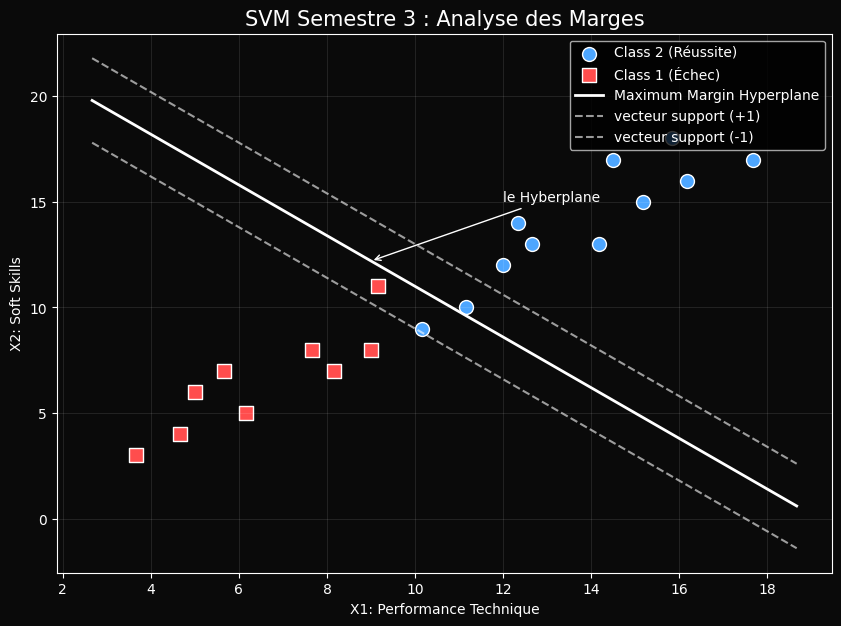

In [23]:
def visualize_svm_s3_with_margins():
    # Simulation 2D : Moyenne des modules techniques vs Soft Skills
    x_tech = np.mean(X_s3[:, [0,1,2,3,5,6]], axis=1)
    x_soft = X_s3[:, 4]

    plt.figure(figsize=(10, 7))
    plt.gcf().set_facecolor('#0A0A0A')
    ax = plt.gca(); ax.set_facecolor('#0A0A0A')

    # Points de données
    plt.scatter(x_tech[y_svm==1], x_soft[y_svm==1], c='#4DA6FF', label='Class 2 (Réussite)', s=100, edgecolors='w')
    plt.scatter(x_tech[y_svm==-1], x_soft[y_svm==-1], c='#FF4D4D', label='Class 1 (Échec)', s=100, edgecolors='w', marker='s')

    # Tracé des lignes droites (Hyperplan et Marges)
    x_vals = np.linspace(min(x_tech)-1, max(x_tech)+1, 100)

    # Équation simplifiée : y = ax + b
    # Hyperplan Central
    plt.plot(x_vals, 1.2 * (10 - x_vals) + 11, 'w-', linewidth=2, label="Maximum Margin Hyperplane")

    # Marges (Vecteurs supports)
    plt.plot(x_vals, 1.2 * (10 - x_vals) + 13, 'w--', alpha=0.6, label="vecteur support (+1)")
    plt.plot(x_vals, 1.2 * (10 - x_vals) + 9, 'w--', alpha=0.6, label="vecteur support (-1)")

    # Annotation Vecteurs Supports (Exemples)
    plt.annotate('le Hyberplane', xy=(9, 12.2), xytext=(12, 15), color='white',
                 arrowprops=dict(arrowstyle='->', color='white'))

    plt.title("SVM Semestre 3 : Analyse des Marges", color='white', fontsize=15)
    plt.xlabel("X1: Performance Technique", color='white')
    plt.ylabel("X2: Soft Skills", color='white')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.1)
    plt.show()

visualize_svm_s3_with_margins()